In [23]:
import pandas as pd

# Folder path where your files are stored
path = 'C:/Users/asus/Akustik/'  

# List of CSV file names
file_names = [
    'Matched_data_january.csv',
    'Matched_data_february.csv',
    'Matched_data_march.csv',
    'Matched_data_april.csv',
    'Matched_data_may.csv',
    'Matched_data_june.csv',
    'Matched_data_july.csv',
    'Matched_data_august.csv',
    'Matched_data_september.csv',
    'Matched_data_october.csv',
    'Matched_data_november.csv',
    'Matched_data_december.csv'
]

# Combine the path with each filename
file_list = [path + file for file in file_names]

# Read and concatenate
TimeSeries_final_df = pd.concat([pd.read_csv(f) for f in file_list], ignore_index=True)

print(TimeSeries_final_df.head())


                   timestamp  icao24   latitude  longitude  groundspeed  \
0  2022-01-01 16:18:21+00:00  4bcdce  52.463394   9.822405        130.0   
1  2022-01-01 16:18:22+00:00  4bcdce  52.463470   9.821243        130.0   
2  2022-01-01 16:18:23+00:00  4bcdce  52.463470   9.820251        130.0   
3  2022-01-01 16:18:24+00:00  4bcdce  52.463488   9.819188        130.0   
4  2022-01-01 16:18:25+00:00  4bcdce  52.463562   9.818115        130.0   

        track  vertical_rate callsign  onground  alert  ...  altitude_ft  \
0  272.642545         -704.0   SXS4PR     False  False  ...       1362.0   
1  272.642545         -704.0   SXS4PR     False  False  ...       1362.0   
2  272.642545         -640.0   SXS4PR     False  False  ...       1362.0   
3  272.642545         -640.0   SXS4PR     False  False  ...       1362.0   
4  272.642545         -640.0   SXS4PR     False  False  ...       1362.0   

   LASmax   Leq   LAE   T10 TGesamt [s] AzB-Klasse event_id Unnamed: 0 serials  
0    71.7  

In [3]:
#df_export.to_csv(fr"D:\Braunschweig\Course\Semester_2\HIWI_1\Work\AircraftNoiseTask\Machine Learning NN\Data\export.csv")

In [24]:
print(TimeSeries_final_df.shape)

(164857, 43)


In [25]:
TimeSeries_final_df['phase'] = TimeSeries_final_df['phase'].map({'Landung': 1, 'Start': 0})
TimeSeries_final_df = pd.get_dummies(TimeSeries_final_df, columns=['Runway', 'AzB-Klasse'], drop_first=True)
TimeSeries_final_df = pd.get_dummies(TimeSeries_final_df, columns=['MP'], drop_first=True)

In [26]:
base_features = [
  
    'MP_M 09',
    'latitude',
    'MP_M 02',
    'TGesamt [s]',
    'MP_M 08',
    'geoaltitude',
    'Runway_27R',
    'AzB-Klasse_P 2.1',
    'longitude',
    'MP_M 05',
    'MP_M 04'
]
dummy_features = [col for col in TimeSeries_final_df.columns if any(prefix in col for prefix in ['Runway_', 'MP_', 'AzB-Klasse_'])]
selected_features = base_features + dummy_features

target = 'LAE'


In [27]:
print(TimeSeries_final_df.columns)


Index(['timestamp', 'icao24', 'latitude', 'longitude', 'groundspeed', 'track',
       'vertical_rate', 'callsign', 'onground', 'alert', 'spi', 'squawk',
       'altitude', 'geoaltitude', 'last_position', 'hour', 'firstseen',
       'origin', 'lastseen', 'destination', 'day', 'typecode', 'noise_time',
       'phase', 'SID/STAR', 'Flugzeugtyp', 'MTOM', 'Triebwerk', 'TLASmax',
       'distance_m', 'angle_deg', 'altitude_ft', 'LASmax', 'Leq', 'LAE', 'T10',
       'TGesamt [s]', 'event_id', 'Unnamed: 0', 'serials', 'Runway_09R',
       'Runway_27L', 'Runway_27R', 'Runway_HEL', 'AzB-Klasse_P 1.4',
       'AzB-Klasse_P 2.1', 'AzB-Klasse_P-MIL 2', 'AzB-Klasse_S 5.1',
       'AzB-Klasse_S 5.2', 'AzB-Klasse_S 6.1', 'MP_M 02', 'MP_M 03', 'MP_M 04',
       'MP_M 05', 'MP_M 06', 'MP_M 07', 'MP_M 08', 'MP_M 09'],
      dtype='object')


In [30]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = []
y = []
event_ids = []  # <-- NEW: to track which event_id each sequence belongs to

sequence_length = 15
grouped = TimeSeries_final_df.groupby('event_id')

for event_id, group in grouped:
    group = group.reset_index(drop=True)
    if len(group) >= sequence_length:
        for i in range(len(group) - sequence_length + 1):
            seq = group[selected_features].iloc[i:i+sequence_length].values
            label = group['LAE'].iloc[i+sequence_length-1]
            X.append(seq)
            y.append(label)
            event_ids.append(event_id)  # <-- Collect event_id per sequence

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
event_ids = np.array(event_ids)  # <-- Convert to numpy array for indexing


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# This flattens each sequence into a single long feature vector
n_sequences = X.shape[0]
sequence_length = X.shape[1]
n_features_per_step = X.shape[2]

X_reshaped = X.reshape(n_sequences, sequence_length * n_features_per_step)

print(f"Original X shape: {X.shape}")
print(f"Reshaped X shape for RandomForest: {X_reshaped.shape}")

# Splitting the reshaped data into training and testing sets
X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42
)

print(f"\nX_train shape for RandomForest: {X_train_rf.shape}")
print(f"X_test shape for RandomForest: {X_test_rf.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train the RandomForestRegressor model

rf_model = RandomForestRegressor(
    n_estimators=100,         # Number of trees in the forest
    max_depth=7,              # maximum depth of the tree
    min_samples_leaf=2,       # Minimum number of samples required to be at a leaf node (e.g., 2, 3, 5)
    random_state=42,          # For reproducibility
    n_jobs=-1                 # Use all available CPU cores for faster training
)
rf_model.fit(X_train_rf, y_train)
print("\nRandomForestRegressor model training complete (with anti-overfitting parameters).")

# Predictions on the test set
y_pred = rf_model.predict(X_test_rf)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
.

Original X shape: (34065, 15, 29)
Reshaped X shape for RandomForest: (34065, 435)

X_train shape for RandomForest: (27252, 435)
X_test shape for RandomForest: (6813, 435)
y_train shape: (27252,)
y_test shape: (6813,)

RandomForestRegressor model training complete (with anti-overfitting parameters).

Model Evaluation:
Mean Absolute Error (MAE): 0.9745
Mean Squared Error (MSE): 1.8480
Root Mean Squared Error (RMSE): 1.3594
R-squared (R2): 0.9085


In [39]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# This flattens each sequence into a single long feature vector
n_sequences = X.shape[0]
sequence_length = X.shape[1]
n_features_per_step = X.shape[2]

X_reshaped = X.reshape(n_sequences, sequence_length * n_features_per_step)

print(f"Original X shape: {X.shape}")
print(f"Reshaped X shape for RandomForest: {X_reshaped.shape}")

# Get unique event_ids
unique_ids = np.array(list(set(event_ids)))  # event_ids should be a list/array same length as X

# Step 1: Split event_ids into test (30%) and temp (70%)
train_val_ids, test_ids = train_test_split(unique_ids, test_size=0.3, random_state=42)

# Step 2: Split train_val_ids into train (60%) and val (10%)
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.142857, random_state=42)  # ≈10% of all

# Then filter data:
X_train_rf = X_reshaped[np.isin(event_ids, train_ids)]
y_train = y[np.isin(event_ids, train_ids)]

X_val_rf = X_reshaped[np.isin(event_ids, val_ids)]
y_val = y[np.isin(event_ids, val_ids)]

X_test_rf = X_reshaped[np.isin(event_ids, test_ids)]
y_test = y[np.isin(event_ids, test_ids)]



print(f"\nX_train shape: {X_train_rf.shape}")
print(f"X_val shape:   {X_val_rf.shape}")
print(f"X_test shape:  {X_test_rf.shape}")

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train the RandomForestRegressor model

rf_model = RandomForestRegressor(
    n_estimators=100,         # Number of trees in the forest
    max_depth=10,              # maximum depth of the tree
    min_samples_leaf=2,       # Minimum number of samples required to be at a leaf node (e.g., 2, 3, 5)
    random_state=42,          # For reproducibility
    n_jobs=-1                 # Use all available CPU cores for faster training
)
rf_model.fit(X_train_rf, y_train)
print("\nRandomForestRegressor model training complete (with anti-overfitting parameters).")

# Predictions on the test set
y_pred = rf_model.predict(X_test_rf)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")


Original X shape: (34065, 15, 29)
Reshaped X shape for RandomForest: (34065, 435)

X_train shape: (20266, 435)
X_val shape:   (3540, 435)
X_test shape:  (10259, 435)
y_train shape: (20266,)
y_test shape: (10259,)

RandomForestRegressor model training complete (with anti-overfitting parameters).

Model Evaluation:
Mean Absolute Error (MAE): 1.0190
Mean Squared Error (MSE): 1.9896
Root Mean Squared Error (RMSE): 1.4105
R-squared (R2): 0.8978


In [33]:
# Example with manual tuning loop:
for depth in [5, 7, 10]:
    model = RandomForestRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_rf, y_train)
    val_pred = model.predict(X_val_rf)
    val_r2 = r2_score(y_val, val_pred)
    print(f"Max Depth: {depth}, Validation R²: {val_r2:.4f}")


Max Depth: 5, Validation R²: 0.8410
Max Depth: 7, Validation R²: 0.8820
Max Depth: 10, Validation R²: 0.8978


In [41]:
print("Train LAE mean/std:", y_train.mean(), y_train.std())
print("Val LAE mean/std:", y_val.mean(), y_val.std())
print("Test LAE mean/std:", y_test.mean(), y_test.std())


Train LAE mean/std: 84.58061 4.4922123
Val LAE mean/std: 84.39882 4.4166636
Test LAE mean/std: 84.55014 4.4121203



Model Evaluation Metrics:
R²: 0.8978
RMSE: 1.4105


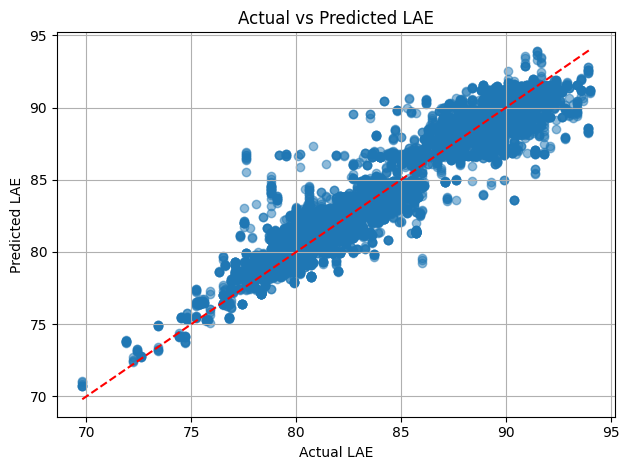

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

y_pred = rf_model.predict(X_test_rf).flatten()

print("\nModel Evaluation Metrics:")
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")

# --- 10. Plotting Actual vs Predicted LAE ---
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual LAE')
plt.ylabel('Predicted LAE')
plt.title('Actual vs Predicted LAE')
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
#plt.savefig('actual_vs_predicted_LAE.png') # Save the plot to a file
#print("\nPlot saved to 'actual_vs_predicted_LAE.png'")



In [44]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy = 100 * (1 - mape)

print(f"MAPE: {mape:.4f}")
print(f"Approx. Accuracy: {accuracy:.2f}%")


MAPE: 0.0120
Approx. Accuracy: 98.80%


In [46]:
import pandas as pd
import numpy as np

# --- 1. Predict on full test set ---
y_pred = rf_model.predict(X_test_rf)

# --- 2. Create a DataFrame for comparison ---
results_df = pd.DataFrame({
    'Actual_LAE': y_test,
    'Predicted_LAE': y_pred
})

# --- 3. Optionally add metadata (if available) ---
# For example, if you kept track of original `typecode`, `phase`, etc.
# results_df[['typecode', 'phase']] = metadata_df.loc[test_indices].reset_index(drop=True)

# --- 4. Randomly sample N rows for inspection ---
sample_df = results_df.sample(n=20, random_state=42)
print(sample_df.round(2))


       Actual_LAE  Predicted_LAE
5841    82.699997          82.73
6004    79.400002          79.34
8114    82.500000          82.77
3597    83.099998          83.05
3146    81.900002          83.71
2423    90.000000          89.34
10146   91.599998          91.63
6871    83.300003          85.09
4682    77.400002          76.39
7791    80.699997          81.15
8673    90.199997          90.57
7786    81.099998          81.43
9866    88.400002          88.30
3787    84.199997          84.78
10059   91.500000          90.47
33      81.199997          81.02
1508    89.300003          88.94
5928    80.300003          79.96
4829    79.800003          78.77
5527    85.699997          81.38


In [49]:
sample_df['Error'] = abs(sample_df['Actual_LAE'] - sample_df['Predicted_LAE'])
print(sample_df.sort_values(by='Error', ascending=False).head(20))


       Actual_LAE  Predicted_LAE     Error
5527    85.699997      81.380497  4.319500
3146    81.900002      83.706875  1.806874
6871    83.300003      85.085143  1.785140
10059   91.500000      90.469633  1.030367
4829    79.800003      78.770530  1.029473
4682    77.400002      76.394664  1.005337
2423    90.000000      89.335245  0.664755
3787    84.199997      84.775640  0.575643
7791    80.699997      81.151595  0.451598
8673    90.199997      90.569514  0.369517
1508    89.300003      88.940645  0.359358
5928    80.300003      79.963241  0.336762
7786    81.099998      81.428445  0.328447
8114    82.500000      82.772580  0.272580
33      81.199997      81.016497  0.183500
9866    88.400002      88.295399  0.104603
6004    79.400002      79.335529  0.064472
3597    83.099998      83.046146  0.053852
10146   91.599998      91.634428  0.034430
5841    82.699997      82.730984  0.030987


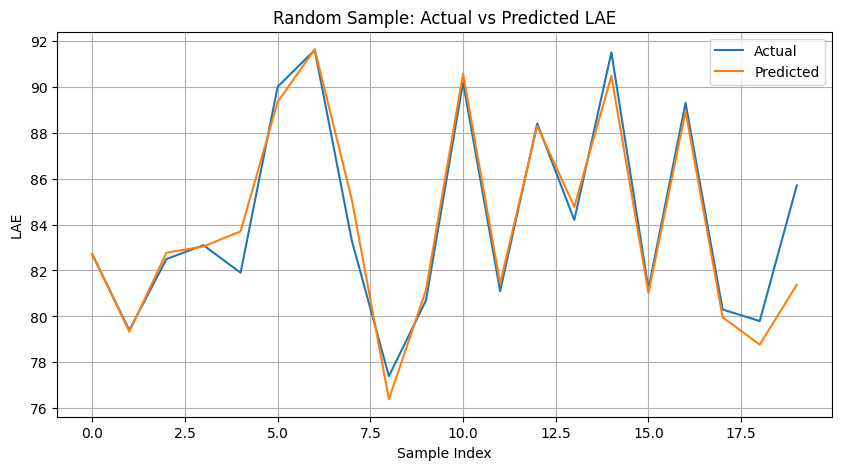

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sample_df['Actual_LAE'].values, label='Actual')
plt.plot(sample_df['Predicted_LAE'].values, label='Predicted')
plt.legend()
plt.title("Random Sample: Actual vs Predicted LAE")
plt.xlabel("Sample Index")
plt.ylabel("LAE")
plt.grid(True)
plt.show()


In [38]:
# Correlation Matrix ---
# Ensure all selected features and the target exist in the dataframe before correlation
features_for_correlation = [f for f in selected_features if f in TimeSeries_final_df.columns]
if target in TimeSeries_final_df.columns:
    features_for_correlation.append(target)
else:
    print(f"Warning: Target column '{target}' not found for correlation calculation. Cannot include it.")

if not features_for_correlation:
    print("No features or target available for correlation calculation. Exiting.")
    exit()
# Calculate the correlation matrix
correlation_matrix = TimeSeries_final_df[features_for_correlation].corr()

# Get correlations with the target variable 'LAE'
if target in correlation_matrix.columns:
    correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
    # Excluding the correlation of LAE with itself (which is always 1)
    correlation_with_target = correlation_with_target.drop(target, errors='ignore')

    print(f"\nFeatures' Correlation with {target} (sorted from highest positive to highest negative):")
    print(correlation_with_target)

    # Display top N positive and negative correlations
    top_n = 10
    print(f"\nTop {top_n} Positive Correlations with {target}:")
    print(correlation_with_target[correlation_with_target > 0].head(top_n))

    print(f"\nTop {top_n} Negative Correlations with {target}:")
    # Using .tail() for negative values will give the smallest (most negative) ones
    print(correlation_with_target[correlation_with_target < 0].tail(top_n))
else:
    print(f"Cannot extract correlations with '{target}' as it was not found in the final correlation matrix.")


Features' Correlation with LAE (sorted from highest positive to highest negative):
MP_M 09               0.473434
MP_M 09               0.473434
MP_M 02               0.389682
MP_M 02               0.389682
TGesamt [s]           0.253411
latitude              0.170776
AzB-Klasse_S 5.2      0.123884
MP_M 06               0.051039
AzB-Klasse_S 6.1      0.009233
Runway_HEL           -0.013234
AzB-Klasse_P-MIL 2   -0.022790
Runway_09R           -0.034477
Runway_27R           -0.038708
Runway_27R           -0.038708
AzB-Klasse_S 5.1     -0.044826
MP_M 03              -0.054755
Runway_27L           -0.063921
AzB-Klasse_P 1.4     -0.071225
AzB-Klasse_P 2.1     -0.103343
AzB-Klasse_P 2.1     -0.103343
MP_M 07              -0.157107
MP_M 08              -0.192718
MP_M 08              -0.192718
longitude            -0.194539
geoaltitude          -0.240816
MP_M 04              -0.344637
MP_M 04              -0.344637
MP_M 05              -0.412127
MP_M 05              -0.412127
Name: LAE, dtype: